<a href="https://colab.research.google.com/github/angelica-gregorio/knn-chronotype/blob/main/GREGORIO_Chronotype_KNN_Activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chronotype Prediction using K-Nearest Neighbors (KNN)

**Submitted by: GREGORIO, Angelica G.**

## Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load the Data

In [ ]:
data = pd.read_excel('chronotype_survey.xlsx')

print("Shape of the dataset (rows, columns):", data.shape)
data.head()

Shape of the dataset (rows, columns): (30, 10)


,last 4 digits id,"On a typical weekday, what time do you usually fall asleep?",How many alarms do you set to wake up in the morning,"How many caffeinated beverages (coffee, energy drinks) do you consume daily?",How many minutes does it take you to fall asleep once you get into bed?,"If you had no classes or obligations, when would you prefer to study/work?",How would you rate your energy level 30 minutes after waking up?,Do you regularly take naps during the day?,Do you regularly eat breakfast within an hour of waking up?,Which best describes your natural chronotype?
0,1150,23:00:00,1,1.0,10,Morning,3,No,Yes,Early Bird
1,285,01:00:00,1,1.0,45,Evening,2,Yes,No,Night Owl
2,2671,21:00:00,2,2.0,10,Afternoon,4,Yes,Yes,Early Bird
3,1971,22:00:00,3,0.0,20,Morning,4,No,Yes,Early Bird
4,609,00:00:00,1,0.0,10,Evening,3,No,Yes,In-Between


## Data Inspection and Pre-Processing

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column                                                                         Non-Null Count  Dtype  
---  ------                                                                         --------------  -----  
 0   last 4 digits id                                                               30 non-null     int64  
 1   On a typical weekday, what time do you usually fall asleep?                    30 non-null     object 
 2   How many alarms do you set to wake up in the morning                           30 non-null     int64  
 3   How many caffeinated beverages (coffee, energy drinks) do you consume daily?   30 non-null     float64
 4   How many minutes does it take you to fall asleep once you get into bed?        30 non-null     int64  
 5   If you had no classes or obligations, when would you prefer to study/work?     30 non-null     object 
 6   How would you rate your ener

In [ ]:
#Give each column a short name
data = data.rename(columns={
    'last 4 digits id': 'id',
    'On a typical weekday, what time do you usually fall asleep?   ': 'sleep_time',
    'How many alarms do you set to wake up in the morning': 'alarms',
    'How many caffeinated beverages (coffee, energy drinks) do you consume daily? ': 'caffeine',
    'How many minutes does it take you to fall asleep once you get into bed?': 'minutes_to_fall_asleep',
    'If you had no classes or obligations, when would you prefer to study/work?': 'preferred_time',
    'How would you rate your energy level 30 minutes after waking up?': 'energy_level',
    'Do you regularly take naps during the day?': 'naps',
    'Do you regularly eat breakfast within an hour of waking up?': 'breakfast',
    'Which best describes your natural chronotype?': 'chronotype'
})

data.head()

,id,sleep_time,alarms,caffeine,minutes_to_fall_asleep,preferred_time,energy_level,naps,breakfast,chronotype
0,1150,23:00:00,1,1.0,10,Morning,3,No,Yes,Early Bird
1,285,01:00:00,1,1.0,45,Evening,2,Yes,No,Night Owl
2,2671,21:00:00,2,2.0,10,Afternoon,4,Yes,Yes,Early Bird
3,1971,22:00:00,3,0.0,20,Morning,4,No,Yes,Early Bird
4,609,00:00:00,1,0.0,10,Evening,3,No,Yes,In-Between


KNN measures the **distance** between two students, so every answer has to become a number first.

| Column | Original form | What I did | Why |
|---|---|---|---|
| `id` | number (e.g. 1150) | **Removed** - not used as a feature | It is just a name tag. Two students with similar id numbers are not similar people. |
| `sleep_time` | clock time (21:00, 01:00) | Converted to **minutes since 12:00 noon**, wrapping past midnight | Explained in detail below. |
| `alarms` | whole number | Used as is | Already numeric and already ordered (3 alarms really is more than 1). |
| `caffeine` | number of drinks | Used as is | Same reason. |
| `minutes_to_fall_asleep` | whole number of minutes | Used as is | Same reason. |
| `preferred_time` | text: Morning / Afternoon / Evening / Late Night | **Ordinal encoding**: 0, 1, 2, 3 | These categories have a natural order through the day, so the numbers keep that order. Morning(0) ends up far from Late Night(3), which is what we want. |
| `energy_level` | rating 1 to 4 | Used as is | It is already an ordered rating scale. |
| `naps` | text: Yes / No | **Binary encoding**: No = 0, Yes = 1 | Only two possible answers, so one 0/1 column is enough. |
| `breakfast` | text: Yes / No | **Binary encoding**: No = 0, Yes = 1 | Same reason. |
| `chronotype` | text label | **Left as text** | This is the answer we are predicting, not an input. KNN never does arithmetic on it, it only counts votes, so it can stay as words. |

**One more step applied to all 8 features:** after the pre-processing above, every feature is
**min-max scaled into the 0-1 range**, using the minimum and maximum taken from the
*training set only*.

**Missing values:** `.info()` above shows 30 non-null values in all 10 columns, so there was nothing to fill in or drop.

### For `sleep_time`:

If we just used the hour number, 11:00 PM would be **23** and 1:00 AM would be **1**, so those
two students would look 22 hours apart even though they went to bed only 2 hours apart.

To fix that, we count **minutes since noon** instead, which puts the whole evening on one continuous line:

For example:
```
noon    6 PM     9 PM    midnight   3 AM     6 AM
 0       360      540       720      900     1080   <-- minutes since noon
```

Now 11 PM = 660 and 1 AM = 780, which is a gap of 120 minutes, exactly the 2 hours it should be.

In [ ]:
# Convert the sleep-time column (a time object) into a single number: "minutes since 12:00 PM (noon)", wrapping around midnight. To keep late bedtimes (11 PM) and very-late bedtimes (1 AM) close together on the number line.

sleep_time_numeric_list = []

for row_index in range(len(data)):
    t = data.loc[row_index, 'sleep_time']
    total_minutes_since_midnight = t.hour * 60 + t.minute
    minutes_since_noon = (total_minutes_since_midnight - 12 * 60) % (24 * 60)
    sleep_time_numeric_list.append(minutes_since_noon)

data['sleep_time_numeric'] = sleep_time_numeric_list

data[['sleep_time', 'sleep_time_numeric']].head()

,sleep_time,sleep_time_numeric
0,23:00:00,660
1,01:00:00,780
2,21:00:00,540
3,22:00:00,600
4,00:00:00,720


In [ ]:
#Ordinal-encode
time_order = {'Morning': 0, 'Afternoon': 1, 'Evening': 2, 'Late Night': 3}
data['preferred_time_numeric'] = data['preferred_time'].map(time_order)

#Binary-encode the Yes/No columns
data['naps_numeric'] = data['naps'].map({'No': 0, 'Yes': 1})
data['breakfast_numeric'] = data['breakfast'].map({'No': 0, 'Yes': 1})

data[['preferred_time', 'preferred_time_numeric', 'naps', 'naps_numeric', 'breakfast', 'breakfast_numeric']].head()

,preferred_time,preferred_time_numeric,naps,naps_numeric,breakfast,breakfast_numeric
0,Morning,0,No,0,Yes,1
1,Evening,2,Yes,1,No,0
2,Afternoon,1,Yes,1,Yes,1
3,Morning,0,No,0,Yes,1
4,Evening,2,No,0,Yes,1


In [ ]:
#Final features to use

feature_columns = [
    'sleep_time_numeric',
    'alarms',
    'caffeine',
    'minutes_to_fall_asleep',
    'preferred_time_numeric',
    'energy_level',
    'naps_numeric',
    'breakfast_numeric'
]

print("Features used for KNN:")
for f in feature_columns:
    print(" -", f)

Features used for KNN:
 - sleep_time_numeric
 - alarms
 - caffeine
 - minutes_to_fall_asleep
 - preferred_time_numeric
 - energy_level
 - naps_numeric
 - breakfast_numeric


## Split into train and test set

In [ ]:
test_df = data.iloc[0:5].reset_index(drop=True)     # rows 1-5
train_df = data.iloc[5:].reset_index(drop=True)      # the rest

print("Training set size:", len(train_df))
print("Test set size:", len(test_df))

test_df[['id', 'chronotype']]

Training set size: 25
Test set size: 5


,id,chronotype
0,1150,Early Bird
1,285,Night Owl
2,2671,Early Bird
3,1971,Early Bird
4,609,In-Between


## Finding the Min and Max for Scaling

In [ ]:
# Grab the raw feature values as plain numpy arrays
X_train_raw = train_df[feature_columns].to_numpy(dtype=float)
X_test_raw = test_df[feature_columns].to_numpy(dtype=float)

y_train = train_df['chronotype'].to_numpy()
y_test = test_df['chronotype'].to_numpy()

num_features = len(feature_columns)

# Finding the min and max of each feature using the training data only
col_min = np.zeros(num_features)
col_max = np.zeros(num_features)

for col_index in range(num_features):
    column_values = X_train_raw[:, col_index]
    col_min[col_index] = column_values.min()
    col_max[col_index] = column_values.max()

pd.DataFrame({'feature': feature_columns, 'train min': col_min, 'train max': col_max})

,feature,train min,train max
0,sleep_time_numeric,540.0,960.0
1,alarms,1.0,15.0
2,caffeine,0.0,2.0
3,minutes_to_fall_asleep,2.0,120.0
4,preferred_time_numeric,0.0,3.0
5,energy_level,1.0,4.0
6,naps_numeric,0.0,1.0
7,breakfast_numeric,0.0,1.0


In [ ]:
# Applying min-max scaling to a matrix of features, one column at a time
def scale_features(X, col_min, col_max):
    X_scaled = np.zeros(X.shape)
    for col_index in range(X.shape[1]):
        min_value = col_min[col_index]
        max_value = col_max[col_index]
        value_range = max_value - min_value
        if value_range == 0:
            value_range = 1
        X_scaled[:, col_index] = (X[:, col_index] - min_value) / value_range
    return X_scaled

X_train = scale_features(X_train_raw, col_min, col_max)
X_test = scale_features(X_test_raw, col_min, col_max)

print("Example: first training student's row BEFORE scaling:")
print(X_train_raw[0])
print()
print("Example: first training student's row AFTER scaling:")
print(X_train[0])

Example: first training student's row BEFORE scaling:
[540.   5.   2.  10.   0.   3.   0.   0.]

Example: first training student's row AFTER scaling:
[0.         0.28571429 1.         0.06779661 0.         0.66666667
 0.         0.        ]


## Visualizing the Features

Since all 8 features are hard to visualize in a 2d or 3d graph, two features were selected for preliminary visualization

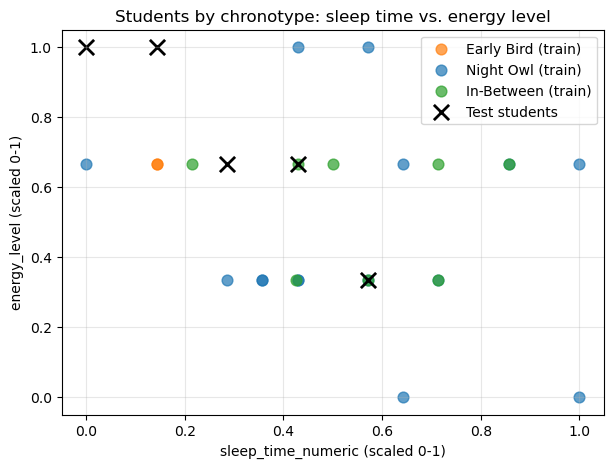

In [ ]:
# Picking two feature columns to plot
x_feature_index = feature_columns.index('sleep_time_numeric')
y_feature_index = feature_columns.index('energy_level')

# One color per chronotype
color_by_label = {
    'Early Bird': 'tab:orange',
    'Night Owl': 'tab:blue',
    'In-Between': 'tab:green'
}

plt.figure(figsize=(7, 5))

# Plot the training students, one chronotype group at a time
for label in color_by_label:
    # Find the rows in the training set that belong to this chronotype
    rows_with_this_label = []
    for i in range(len(y_train)):
        if y_train[i] == label:
            rows_with_this_label.append(i)

    plt.scatter(
        X_train[rows_with_this_label, x_feature_index],
        X_train[rows_with_this_label, y_feature_index],
        color=color_by_label[label],
        label=f"{label} (train)",
        alpha=0.7,
        s=60
    )

# Plot the test students on top, as black X marks
plt.scatter(
    X_test[:, x_feature_index],
    X_test[:, y_feature_index],
    color='black',
    marker='x',
    s=120,
    linewidths=2,
    label='Test students'
)

plt.xlabel('sleep_time_numeric (scaled 0-1)')
plt.ylabel('energy_level (scaled 0-1)')
plt.title('Students by chronotype: sleep time vs. energy level')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Implementing the Euclidean Distance

The Euclidean distance between two feature vectors $a$ and $b$ (each with $n$ features) is:

$$d(a, b) = \sqrt{\sum_{i=1}^{n} (a_i - b_i)^2}$$

Subtract the two vectors feature-by-feature, square every difference, add all the squares together, then take the square root.

In [ ]:
def euclidean_distance(point_a, point_b):
    sum_of_squared_differences = 0.0
    for i in range(len(point_a)):
        difference = point_a[i] - point_b[i]
        sum_of_squared_differences = sum_of_squared_differences + difference ** 2
    distance = np.sqrt(sum_of_squared_differences)
    return distance

Testing the function on student 1

In [ ]:
a = X_test[0]
b = X_train[0]

running_total = 0.0
print(f"{'feature':<24}{'test':>8}{'train':>8}{'diff':>8}{'diff^2':>10}")
for i in range(len(a)):
    difference = a[i] - b[i]
    running_total = running_total + difference ** 2
    print(f"{feature_columns[i]:<24}{a[i]:>8.3f}{b[i]:>8.3f}{difference:>8.3f}{difference**2:>10.3f}")

print()
print("Sum of the squared differences :", round(running_total, 3))
print("Square root of that sum        :", round(np.sqrt(running_total), 3))
print("What our function returns      :", round(euclidean_distance(a, b), 3))

feature                     test   train    diff    diff^2
sleep_time_numeric         0.286   0.000   0.286     0.082
alarms                     0.000   0.286  -0.286     0.082
caffeine                   0.500   1.000  -0.500     0.250
minutes_to_fall_asleep     0.068   0.068   0.000     0.000
preferred_time_numeric     0.000   0.000   0.000     0.000
energy_level               0.667   0.667   0.000     0.000
naps_numeric               0.000   0.000   0.000     0.000
breakfast_numeric          1.000   0.000   1.000     1.000

Sum of the squared differences : 1.413
Square root of that sum        : 1.189
What our function returns      : 1.189


In [ ]:
## Displaying the full distance table
num_test = X_test.shape[0]
num_train = X_train.shape[0]

# distance_table[i, j] = distance between test student i and training student j
distance_table = np.zeros((num_test, num_train))

for i in range(num_test):
    for j in range(num_train):
        distance_table[i, j] = euclidean_distance(X_test[i], X_train[j])

# Making it in Panda Dataframe
distance_df = pd.DataFrame(
    distance_table,
    index=["Test " + str(i + 1) + " (id " + str(test_df.loc[i, 'id']) + ")" for i in range(num_test)],
    columns=["Train " + str(j + 1) + " (id " + str(train_df.loc[j, 'id']) + ")" for j in range(num_train)]
)

distance_df.round(3)

,Train 1 (id 5860),Train 2 (id 8137),Train 3 (id 6136),Train 4 (id 4477),Train 5 (id 1162),Train 6 (id 4501),Train 7 (id 412),Train 8 (id 8390),Train 9 (id 9112),Train 10 (id 5029),...,Train 16 (id 8382),Train 17 (id 1517),Train 18 (id 7254),Train 19 (id 469),Train 20 (id 1373),Train 21 (id 3323),Train 22 (id 2780),Train 23 (id 6381),Train 24 (id 8277),Train 25 (id 8779)
Test 1 (id 1150),1.189,1.255,0.954,1.267,1.517,1.940,1.228,0.611,1.101,1.589,...,1.589,1.691,1.474,1.943,1.178,1.392,1.602,1.362,1.429,1.776
Test 2 (id 285),1.517,1.212,1.555,1.057,1.716,0.849,1.188,1.626,1.503,0.666,...,0.717,1.294,1.206,0.768,1.305,1.170,0.638,1.316,0.827,1.573
Test 3 (id 2671),1.506,1.943,1.669,1.709,1.827,1.601,0.805,1.473,1.533,1.614,...,1.555,2.223,1.998,1.864,0.790,1.347,1.633,1.824,1.289,2.006
Test 4 (id 1971),1.469,1.322,0.996,1.472,1.731,2.206,1.630,0.498,1.310,1.615,...,1.678,1.719,1.444,1.933,1.252,1.414,1.633,1.246,1.565,1.864
Test 5 (id 609),1.646,1.124,0.441,1.196,1.859,1.855,1.496,0.405,0.687,1.509,...,1.543,1.436,1.182,1.579,1.255,1.105,1.522,1.068,1.648,1.779


## Implement KNN Classifier

In [ ]:
def find_k_nearest(distances, k):
    """
    distances : the distances from ONE test student to every training student
    k         : how many neighbours we want
    returns   : the positions of the k smallest distances, closest first
    """
    remaining = list(distances)    # work on a copy so the original table is not damaged
    nearest_positions = []

    for step in range(k):
        # assume the first one is the smallest, then check all the others
        smallest_position = 0
        smallest_value = remaining[0]

        for position in range(len(remaining)):
            if remaining[position] < smallest_value:
                smallest_value = remaining[position]
                smallest_position = position

        nearest_positions.append(smallest_position)
        remaining[smallest_position] = 999999    # cross it out so it is never picked again

    return nearest_positions


# Quick check on a tiny made-up list: the two smallest are 0.1 (position 2) and 0.4 (position 0)
print(find_k_nearest([0.4, 0.9, 0.1, 0.7], 2))

[2, 0]


In [ ]:
# For each test student, show the 5 closest training students

for i in range(num_test):
    print(f"--- Test student {i+1} (id {test_df.loc[i, 'id']}), actual chronotype: {y_test[i]} ---")

    # positions of the 5 closest training students, closest first
    nearest_positions = find_k_nearest(distance_table[i], 5)

    rows = []
    for position in nearest_positions:
        rows.append({
            'train_id': train_df.loc[position, 'id'],
            'distance': round(distance_table[i, position], 3),
            'chronotype': y_train[position]
        })

    print(pd.DataFrame(rows).to_string(index=False))
    print()

--- Test student 1 (id 1150), actual chronotype: Early Bird ---
 train_id  distance chronotype
     8390     0.611 In-Between
     1114     0.628 Early Bird
     6136     0.954  Night Owl
     4286     1.065 Early Bird
     9112     1.101 In-Between

--- Test student 2 (id 285), actual chronotype: Night Owl ---
 train_id  distance chronotype
     2780     0.638  Night Owl
     5029     0.666  Night Owl
     8382     0.717 In-Between
      469     0.768  Night Owl
     8277     0.827 In-Between

--- Test student 3 (id 2671), actual chronotype: Early Bird ---
 train_id  distance chronotype
     4286     0.623 Early Bird
     1373     0.790  Night Owl
      412     0.805 In-Between
     7637     1.125  Night Owl
     8277     1.289 In-Between

--- Test student 4 (id 1971), actual chronotype: Early Bird ---
 train_id  distance chronotype
     1114     0.477 Early Bird
     8390     0.498 In-Between
     6136     0.996  Night Owl
     4286     1.228 Early Bird
     6381     1.246  Night Owl

In [ ]:
def count_votes(neighbour_labels):
    """Count how many times each chronotype appears. Returns two matching lists."""
    names = []
    counts = []

    for label in neighbour_labels:
        if label in names:
            position = names.index(label)       # where this chronotype already sits
            counts[position] = counts[position] + 1
        else:
            names.append(label)                 # a chronotype we have not seen yet
            counts.append(1)

    return names, counts


def majority_vote(neighbour_labels):
    """Return the winning chronotype. neighbour_labels must be ordered closest first."""
    names, counts = count_votes(neighbour_labels)

    # find the highest vote count
    highest_count = 0
    for c in counts:
        if c > highest_count:
            highest_count = c

    # collect everyone who reached that count (usually one, sometimes more)
    winners = []
    for i in range(len(names)):
        if counts[i] == highest_count:
            winners.append(names[i])

    if len(winners) == 1:
        return winners[0]

    # TIE: walk from the closest neighbour outwards and take the first tied label we meet
    for label in neighbour_labels:
        if label in winners:
            return label


# Sanity check
print(majority_vote(['Night Owl', 'In-Between', 'Night Owl']))   # clear winner -> Night Owl
print(majority_vote(['In-Between', 'Early Bird', 'Night Owl']))  # 3-way tie -> closest wins

Night Owl
In-Between


In [ ]:
def knn_predict_one(distances_to_train, y_train, k):
    """Predict the chronotype of ONE test student."""
    nearest_positions = find_k_nearest(distances_to_train, k)

    neighbour_labels = []
    for position in nearest_positions:
        neighbour_labels.append(y_train[position])

    return majority_vote(neighbour_labels)


def knn_predict(distance_table, y_train, k):
    """Predict the chronotype of EVERY test student."""
    predictions = []
    for i in range(distance_table.shape[0]):     # shape[0] is the number of test students
        predictions.append(knn_predict_one(distance_table[i], y_train, k))
    return np.array(predictions)

In [ ]:
def accuracy(y_true, y_pred):
    correct_count = 0
    for i in range(len(y_true)):
        if y_true[i] == y_pred[i]:
            correct_count = correct_count + 1
    return correct_count / len(y_true)


results = {}   # will store {k: (predictions, accuracy)}

for k in [1, 3, 5]:
    y_pred = knn_predict(distance_table, y_train, k)
    acc = accuracy(y_test, y_pred)
    results[k] = (y_pred, acc)
    num_correct = round(acc * len(y_test))
    print(f"K = {k}  ->  Accuracy = {acc:.2f}  ({num_correct}/{len(y_test)} correct)")

K = 1  ->  Accuracy = 0.80  (4/5 correct)
K = 3  ->  Accuracy = 0.80  (4/5 correct)
K = 5  ->  Accuracy = 0.60  (3/5 correct)


In [ ]:
comparison = pd.DataFrame({
    'student_id': test_df['id'],
    'actual': y_test,
    'K=1 prediction': results[1][0],
    'K=3 prediction': results[3][0],
    'K=5 prediction': results[5][0],
})
comparison

,student_id,actual,K=1 prediction,K=3 prediction,K=5 prediction
0,1150,Early Bird,In-Between,In-Between,In-Between
1,285,Night Owl,Night Owl,Night Owl,Night Owl
2,2671,Early Bird,Early Bird,Early Bird,Night Owl
3,1971,Early Bird,Early Bird,Early Bird,Early Bird
4,609,In-Between,In-Between,In-Between,In-Between


In [ ]:
best_k = 1
best_acc = results[1][1]

for k in [1, 3, 5]:
    if results[k][1] > best_acc:
        best_acc = results[k][1]
        best_k = k

# If more than one K can reach the same best accuracy, list all of them
all_best = []
for k in [1, 3, 5]:
    if results[k][1] == best_acc:
        all_best.append(k)

print("Best accuracy on this test set:", round(best_acc, 2))
print("Reached by K =", all_best)

Best accuracy on this test set: 0.8
Reached by K = [1, 3]


## Conclusion

K = 1 and K = 3 both got 4 out of 5 correct (0.80), while K = 5 only got 3 out of 5 (0.60), so
K = 1 and K = 3 are the best choices on this test set.

K = 5 does worse because of how the split turned out. Only 2 of the 25 training students are
Early Birds, so an Early Bird can never collect more than 2 votes out of 5 and can never win a
majority. That is what happens to student 2671, who is correct at K = 1 and K = 3 but flips to
Night Owl at K = 5. Student 1150 is wrong at every K because its two closest neighbours are an
In-Between and a Night Owl, so its answers sit nearer to that group than to the two Early Birds
in the training data.

One thing to keep in mind is that the test set is only 5 students, so each one is worth 20% of
the accuracy. The gap between 0.80 and 0.60 is really just one prediction changing.

## Comparing with Z-score Standardization

Everything above used **min-max scaling**, which squeezes every feature into the range [0, 1] based on the min and max of the training data.

Another option is **z-score standardization**, which instead centers each feature around 0 using the training mean and spreads it out based on the training standard deviation:

$$z = \frac{x - \text{mean}}{\text{std}}$$

Unlike min-max, z-scored features are not bounded to [0, 1],most values fall roughly between -3 and 3, and outliers stand out more instead of being squashed toward the edges. This section repeats the same distance calculation, KNN classifier, and accuracy check, but with z-score scaling instead of min-max, to see whether the choice of scaling changes the predictions.

### Finding the Mean and Standard Deviation for Scaling

In [ ]:
# Finding the mean and standard deviation of each feature using the training data only
col_mean = np.zeros(num_features)
col_std = np.zeros(num_features)

for col_index in range(num_features):
    column_values = X_train_raw[:, col_index]
    col_mean[col_index] = column_values.mean()
    col_std[col_index] = column_values.std()

pd.DataFrame({'feature': feature_columns, 'train mean': col_mean, 'train std': col_std})

,feature,train mean,train std
0,sleep_time_numeric,758.36,107.520000
1,alarms,3.40,3.149603
2,caffeine,0.70,0.774597
3,minutes_to_fall_asleep,34.20,33.239735
4,preferred_time_numeric,1.44,0.941488
5,energy_level,2.52,0.754718
6,naps_numeric,0.48,0.499600
7,breakfast_numeric,0.40,0.489898


In [ ]:
# Applying z-score standardization to a matrix of features, one column at a time
def standardize_features(X, col_mean, col_std):
    X_scaled = np.zeros(X.shape)
    for col_index in range(X.shape[1]):
        mean_value = col_mean[col_index]
        std_value = col_std[col_index]
        if std_value == 0:
            std_value = 1
        X_scaled[:, col_index] = (X[:, col_index] - mean_value) / std_value
    return X_scaled

X_train_z = standardize_features(X_train_raw, col_mean, col_std)
X_test_z = standardize_features(X_test_raw, col_mean, col_std)

print("Example: first training student's row BEFORE scaling:")
print(X_train_raw[0])
print()
print("Example: first training student's row AFTER z-score scaling:")
print(X_train_z[0])
print()
print("Example: same row after min-max scaling (for comparison):")
print(X_train[0])

Example: first training student's row BEFORE scaling:
[540.   5.   2.  10.   0.   3.   0.   0.]

Example: first training student's row AFTER z-score scaling:
[-2.03087798  0.50800051  1.67829278 -0.72804431 -1.52949344  0.63599873
 -0.96076892 -0.81649658]

Example: same row after min-max scaling (for comparison):
[0.         0.28571429 1.         0.06779661 0.         0.66666667
 0.         0.        ]


### Distance Table and KNN with Z-score Scaling

The same `euclidean_distance`, `find_k_nearest`, `majority_vote`, and `knn_predict` functions from before are reused here, only the scaled features will be different.

In [ ]:
# Rebuilding the distance table, this time using the z-scored features
distance_table_z = np.zeros((num_test, num_train))

for i in range(num_test):
    for j in range(num_train):
        distance_table_z[i, j] = euclidean_distance(X_test_z[i], X_train_z[j])

distance_df_z = pd.DataFrame(
    distance_table_z,
    index=["Test " + str(i + 1) + " (id " + str(test_df.loc[i, 'id']) + ")" for i in range(num_test)],
    columns=["Train " + str(j + 1) + " (id " + str(train_df.loc[j, 'id']) + ")" for j in range(num_train)]
)

distance_df_z.round(3)

,Train 1 (id 5860),Train 2 (id 8137),Train 3 (id 6136),Train 4 (id 4477),Train 5 (id 1162),Train 6 (id 4501),Train 7 (id 412),Train 8 (id 8390),Train 9 (id 9112),Train 10 (id 5029),...,Train 16 (id 8382),Train 17 (id 1517),Train 18 (id 7254),Train 19 (id 469),Train 20 (id 1373),Train 21 (id 3323),Train 22 (id 2780),Train 23 (id 6381),Train 24 (id 8277),Train 25 (id 8779)
Test 1 (id 1150),2.948,3.220,3.144,3.347,5.133,5.273,3.010,1.721,3.649,3.683,...,3.892,5.085,4.090,5.258,3.126,3.772,3.730,3.574,2.981,5.748
Test 2 (id 285),4.432,2.883,3.547,2.421,5.784,2.858,2.765,3.903,3.402,2.025,...,2.558,3.328,2.935,2.530,3.840,2.822,1.870,3.635,2.845,4.648
Test 3 (id 2671),3.459,5.191,4.749,4.438,5.654,5.081,3.178,3.650,4.493,4.502,...,4.586,6.467,5.345,5.539,2.753,4.346,4.584,4.386,3.409,7.121
Test 4 (id 1971),3.660,3.900,3.634,4.215,5.417,6.196,4.525,1.834,4.365,4.137,...,4.418,5.490,4.232,5.414,3.167,4.157,4.242,3.228,3.596,6.362
Test 5 (id 609),4.445,2.787,1.842,2.944,5.936,4.580,3.710,1.385,2.098,3.450,...,3.601,4.257,3.050,3.843,3.241,2.782,3.499,2.507,3.841,5.752


In [ ]:
results_z = {}   # will store {k: (predictions, accuracy)} for the z-score scaled features

for k in [1, 3, 5]:
    y_pred_z = knn_predict(distance_table_z, y_train, k)
    acc_z = accuracy(y_test, y_pred_z)
    results_z[k] = (y_pred_z, acc_z)
    num_correct_z = round(acc_z * len(y_test))
    print(f"K = {k}  ->  Accuracy = {acc_z:.2f}  ({num_correct_z}/{len(y_test)} correct)")

K = 1  ->  Accuracy = 0.80  (4/5 correct)
K = 3  ->  Accuracy = 1.00  (5/5 correct)
K = 5  ->  Accuracy = 0.60  (3/5 correct)


### Min-Max vs Z-score: Side-by-Side Comparison

In [ ]:
comparison_z = pd.DataFrame({
    'student_id': test_df['id'],
    'actual': y_test,
    'K=1 (min-max)': results[1][0],
    'K=1 (z-score)': results_z[1][0],
    'K=3 (min-max)': results[3][0],
    'K=3 (z-score)': results_z[3][0],
    'K=5 (min-max)': results[5][0],
    'K=5 (z-score)': results_z[5][0],
})
comparison_z

,student_id,actual,K=1 (min-max),K=1 (z-score),K=3 (min-max),K=3 (z-score),K=5 (min-max),K=5 (z-score)
0,1150,Early Bird,In-Between,In-Between,In-Between,Early Bird,In-Between,In-Between
1,285,Night Owl,Night Owl,Night Owl,Night Owl,Night Owl,Night Owl,Night Owl
2,2671,Early Bird,Early Bird,Early Bird,Early Bird,Early Bird,Night Owl,Night Owl
3,1971,Early Bird,Early Bird,Early Bird,Early Bird,Early Bird,Early Bird,Early Bird
4,609,In-Between,In-Between,In-Between,In-Between,In-Between,In-Between,In-Between


In [ ]:
accuracy_summary = pd.DataFrame({
    'K': [1, 3, 5],
    'Accuracy (min-max)': [results[1][1], results[3][1], results[5][1]],
    'Accuracy (z-score)': [results_z[1][1], results_z[3][1], results_z[5][1]],
})
accuracy_summary

,K,Accuracy (min-max),Accuracy (z-score)
0,1,0.8,0.8
1,3,0.8,1.0
2,5,0.6,0.6



### Discussion

Running the notebook on the actual data gives:

| K | Accuracy (min-max) | Accuracy (z-score) |
|---|---|---|
| 1 | 0.80 | 0.80 |
| 3 | 0.80 | 1.00 |
| 5 | 0.60 | 0.60 |

K = 1 and K = 5 land on the same accuracy under both scaling methods, but K = 3 improves from
0.80 to 1.00 under z-score scaling, one of the two students misclassified under min-max at
K = 3 gets corrected. Z-score never does worse than min-max at any K, so on this dataset it is
the safer choice.

A likely reason: `sleep_time_numeric` ranges over roughly 0–1440 minutes, far wider than the
other 7 features (ratings, counts, and 0/1-encoded features). Min-max squeezes every feature
into [0, 1] using only its min and max, so if `sleep_time_numeric` isn't spread evenly across
that full range in the training data, it can still end up influencing distance more than the
smaller features. Z-score instead scales each feature by its own standard deviation, which
better reflects how spread out the training students actually are on that feature. That
difference in weighting is enough to change the neighbor ranking for one test student at K = 3.